# 03 Test Siamese Network

This notebook tests the custom Siamese network on the payload loss test dataset. The model compares each current frame against an initial reference frame and outputs a payload loss score from 0 to 1, where higher scores indicate a higher likelihood of payload loss.

## 1. Imports and setup

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils import GROUND_TRUTH_CSV, resolve_test_video_path
from src.siamese_method import SiameseMethod
from src.evaluate import evaluate_method

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load Ground Truth

Load the test dataset annotations from `ground_truth.csv`.

In [4]:
gt = pd.read_csv(GROUND_TRUTH_CSV)
gt.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411


## 3. Inspect One Video

Select one video from the dataset and run the Siamese network on it to check whether the score increases around the payload loss event.

In [5]:
# Pick one video to inspect
row = gt.iloc[0]
video_path = resolve_test_video_path(row["filename"])

row, video_path

(filename         videos_normal/indoor_full/front_empty_001.mp4
 camera_id                                                front
 is_loss_event                                                0
 loss_frame                                                  -1
 total_frames                                               410
 Name: 0, dtype: object,
 PosixPath('/Users/tohjiale/Desktop/payload_loss_detection/test_data/videos_normal/indoor_full/front_empty_001.mp4'))

## 4. Test Siamese network on one video

In [6]:
method = SiameseMethod(threshold=0.5, consecutive_frames=5)

result = method.predict_video(video_path)

print("Detected frame:", result["detected_frame"])
print("Ground truth loss frame:", row["loss_frame"])

Detected frame: -1
Ground truth loss frame: -1


## 5. Plot Siamese Score

The plot shows the Siamese network score over time. A higher score indicates a higher likelihood of payload loss.

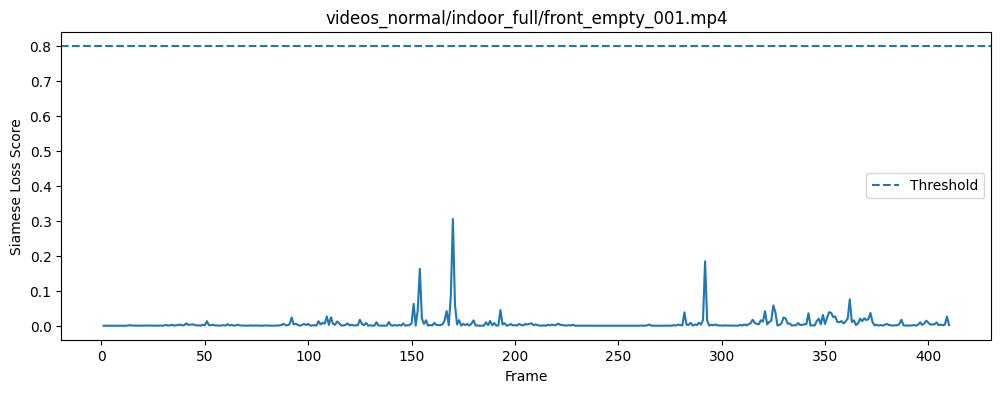

In [23]:
frames = list(range(1, len(result["scores"]) + 1))

plt.figure(figsize=(12, 4))
plt.plot(frames, result["scores"])
plt.axhline(method.threshold, linestyle="--", label="Threshold")

if row["is_loss_event"] == 1:
    plt.axvline(row["loss_frame"], linestyle="--", label="Ground Truth Loss Frame")

if result["detected_frame"] != -1:
    plt.axvline(result["detected_frame"], linestyle=":", label="Detected Frame")

plt.xlabel("Frame")
plt.ylabel("Siamese Loss Score")
plt.title(row["filename"])
plt.legend()
# plt.savefig("results/fig13_siamese_detection.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Evaluate Siamese Network on Full Test Dataset

Run the Siamese network on all test videos and compute event-level, frame-level, and latency metrics.

In [8]:
method = SiameseMethod(threshold=0.5, consecutive_frames=5)

video_results, frame_results, metrics = evaluate_method(method)

metrics

{'event_level_recall': np.float64(0.6111111111111112),
 'event_level_precision': np.float64(0.5301204819277109),
 'frame_level_precision': np.float64(0.5743614613643712),
 'avg_detection_delay_frames': np.float64(13.181818181818182),
 'avg_latency_ms': np.float64(87.28487885630123)}

### Video-Level Results

Preview of evaluation results at the video level, including detected frame and ground truth labels.

In [9]:
video_results.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames,detected_frame
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410,-1
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408,-1
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406,-1
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404,-1
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411,258


### Frame-Level Results

Preview of per-frame predictions, scores, and inference latency for all videos.

In [10]:
frame_results.head()

,filename,camera_id,is_loss_event,loss_frame,frame_idx,score,pred_frame_loss,inference_time_ms
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,1,0.000000e+00,0,88.044417
1,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,2,3.676790e-15,0,87.025500
2,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,3,5.341196e-11,0,87.380916
3,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,4,5.083861e-13,0,86.656833
4,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,5,4.855664e-13,0,89.906584


## 7. Threshold Sweep

The Siamese network outputs a score from 0 to 1, so this section tests different classification thresholds, from 0.10 to 0.90, in steps of 0.05.

In [ ]:
sweep_results = []

thresholds = [round(0.10 + i * 0.05, 2) for i in range(17)]

for threshold in thresholds:
    method = SiameseMethod(threshold=threshold, consecutive_frames=5)
    _, _, metrics = evaluate_method(method)

    sweep_results.append({
        "threshold": threshold,
        **metrics
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

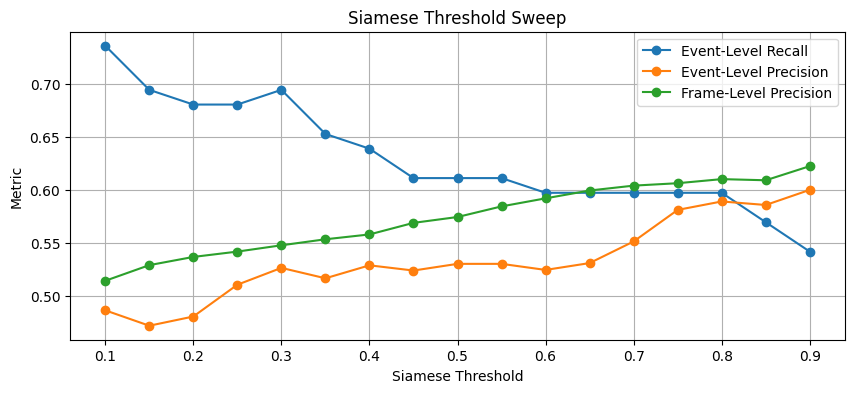

In [20]:
# Plot threshold sweep

plt.figure(figsize=(10, 4))
plt.plot(sweep_df["threshold"], sweep_df["event_level_recall"], marker="o", label="Event-Level Recall")
plt.plot(sweep_df["threshold"], sweep_df["event_level_precision"], marker="o", label="Event-Level Precision")
plt.plot(sweep_df["threshold"], sweep_df["frame_level_precision"], marker="o", label="Frame-Level Precision")

plt.xlabel("Siamese Threshold")
plt.ylabel("Metric")
plt.title("Siamese Threshold Sweep")
plt.legend()
plt.grid(True)
# plt.savefig("results/fig14_siamese_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Consecutive Frame Filtering

This section evaluates how temporal filtering affects detection performance. Instead of triggering payload loss from a single high-score frame, the model must predict loss for multiple consecutive frames before confirming an event. This can reduce false positives caused by short score spikes.

The full threshold sweep from 0.1 to 0.9 was computationally expensive, so only three representative thresholds are tested here: 0.1 for high recall, 0.3 for a balanced setting, and 0.8 for higher precision. Each threshold is tested with 1, 3, and 5 consecutive-frame requirements to identify a practical trade-off between recall, precision, and detection delay.

In [15]:
filter_results = []

thresholds = [0.1, 0.3, 0.8]
consecutive_options = [1, 3, 5]

for thr in thresholds:
    for cf in consecutive_options:
        print(f"Evaluating threshold={thr}, consecutive_frames={cf}...")
        
        method = SiameseMethod(threshold=thr, consecutive_frames=cf)
        _, _, metrics = evaluate_method(method)

        filter_results.append({
            "threshold": thr,
            "consecutive_frames": cf,
            **metrics
        })

filter_df = pd.DataFrame(filter_results)
filter_df.sort_values(by="event_level_recall", ascending=False)

Evaluating threshold=0.1, consecutive_frames=1...
Evaluating threshold=0.1, consecutive_frames=3...
Evaluating threshold=0.1, consecutive_frames=5...
Evaluating threshold=0.3, consecutive_frames=1...
Evaluating threshold=0.3, consecutive_frames=3...
Evaluating threshold=0.3, consecutive_frames=5...
Evaluating threshold=0.8, consecutive_frames=1...
Evaluating threshold=0.8, consecutive_frames=3...
Evaluating threshold=0.8, consecutive_frames=5...


,threshold,consecutive_frames,event_level_recall,event_level_precision,frame_level_precision,avg_detection_delay_frames,avg_latency_ms
1,0.1,3,0.763889,0.466102,0.504248,-1.018182,86.700773
2,0.1,5,0.736111,0.486239,0.514126,10.792453,86.959043
6,0.8,1,0.736111,0.477477,0.534061,1.735849,87.110411
0,0.1,1,0.722222,0.385185,0.484705,-4.000000,87.320763
3,0.3,1,0.722222,0.409449,0.501605,-2.153846,83.901222
4,0.3,3,0.694444,0.480769,0.530407,4.740000,81.548540
5,0.3,5,0.694444,0.526316,0.547649,15.500000,87.709296
7,0.8,3,0.625000,0.542169,0.583485,7.800000,87.962149
8,0.8,5,0.597222,0.589041,0.610133,14.279070,87.556070


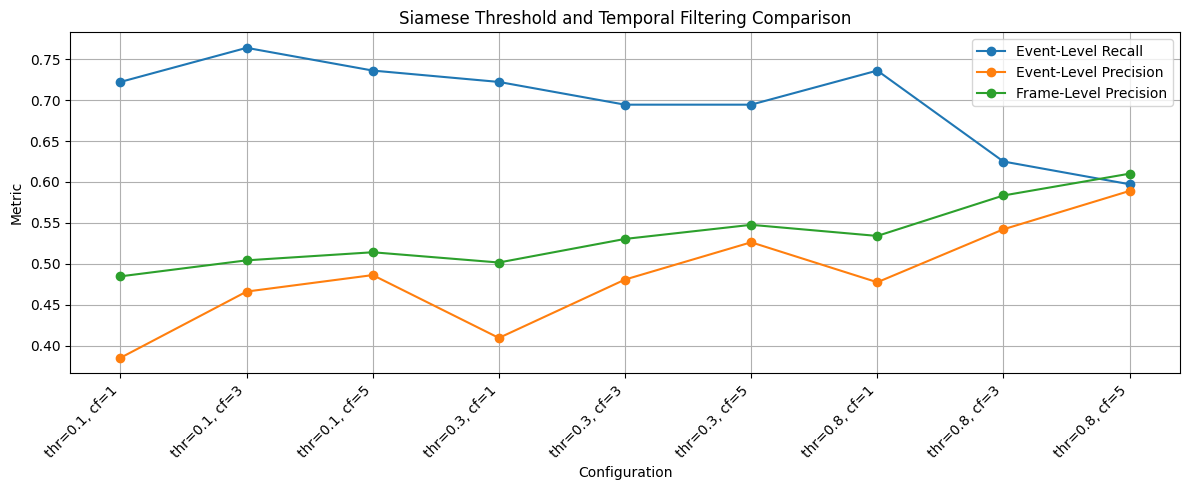

In [22]:
plot_df = filter_df.sort_values(["threshold", "consecutive_frames"]).copy()
plot_df["config"] = plot_df.apply(
    lambda row: f"thr={row['threshold']}, cf={int(row['consecutive_frames'])}",
    axis=1
)

plt.figure(figsize=(12, 5))
plt.plot(plot_df["config"], plot_df["event_level_recall"], marker="o", label="Event-Level Recall")
plt.plot(plot_df["config"], plot_df["event_level_precision"], marker="o", label="Event-Level Precision")
plt.plot(plot_df["config"], plot_df["frame_level_precision"], marker="o", label="Frame-Level Precision")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Configuration")
plt.ylabel("Metric")
plt.title("Siamese Threshold and Temporal Filtering Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("results/fig15_siamese_filtering_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Save Results

Save Siamese network results for later comparison with SSIM and YOLO26n.

In [18]:
output_dir = PROJECT_ROOT / "notebooks" / "results"
output_dir.mkdir(exist_ok=True)

video_results.to_csv(output_dir / "siamese_video_results.csv", index=False)
frame_results.to_csv(output_dir / "siamese_frame_results.csv", index=False)
sweep_df.to_csv(output_dir / "siamese_threshold_sweep.csv", index=False)
filter_df.to_csv(output_dir / "siamese_filter_sweep.csv", index=False)

print("Saved Siamese results.")

Saved Siamese results.


## 10. Conclusion

The Siamese network demonstrates strong performance for payload loss detection, outperforming both SSIM and YOLO-based approaches by directly comparing the current payload state against a reference state. 

The threshold sweep (Section 7) shows the expected trade-off between recall and precision, where lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missed detections. 

To improve robustness, temporal filtering was applied (Section 8), requiring multiple consecutive loss predictions before triggering an event. This reduces noise from short score spikes and stabilizes detection.

From the combined threshold and filtering experiments, a configuration of **threshold = 0.10** and **consecutive_frames = 3** was selected. This setting provides the best trade-off, achieving high event-level recall while maintaining reasonable precision and low detection delay. Notably, temporal filtering also improves detection consistency and reduces delayed detections compared to stricter configurations.

Overall, the Siamese network is effective for this task, providing reliable detection performance with acceptable latency for deployment.

---

## Addendum - Identifying Model Weaknesses

In [25]:
video_results["event_class"] = video_results["filename"].apply(lambda x: Path(x).parts[0])
video_results["lighting"] = video_results["filename"].apply(lambda x: Path(x).parts[1])
video_results["video_name"] = video_results["filename"].apply(lambda x: Path(x).name)

In [26]:
# Identify failed videos
EARLY_TOLERANCE_FRAMES = 60  # match your utils.py

video_results["correct_detection"] = (
    (video_results["is_loss_event"] == 1) &
    (video_results["detected_frame"] != -1) &
    (video_results["detected_frame"] >= (video_results["loss_frame"] - EARLY_TOLERANCE_FRAMES))
) | (
    (video_results["is_loss_event"] == 0) &
    (video_results["detected_frame"] == -1)
)

failed_videos = video_results[~video_results["correct_detection"]].copy()
failed_videos[["filename", "is_loss_event", "loss_frame", "detected_frame", "lighting"]]

,filename,is_loss_event,loss_frame,detected_frame,lighting
4,videos_normal/indoor_med/front_empty_001.mp4,0,-1,258,indoor_med
5,videos_normal/indoor_med/back_empty_001.mp4,0,-1,219,indoor_med
6,videos_normal/indoor_med/left_empty_001.mp4,0,-1,353,indoor_med
8,videos_normal/indoor_low/front_empty_001.mp4,0,-1,85,indoor_low
9,videos_normal/indoor_low/back_empty_001.mp4,0,-1,128,indoor_low
...,...,...,...,...,...
134,videos_normal/indoor_low/left_bottle1toolbox1_...,0,-1,97,indoor_low
135,videos_normal/indoor_low/right_bottle1toolbox1...,0,-1,48,indoor_low
137,videos_loss/indoor_low/back_bottle1toolbox1_lo...,1,150,-1,indoor_low
139,videos_loss/indoor_low/right_bottle1toolbox1_l...,1,150,-1,indoor_low


In [27]:
failure_summary = failed_videos.groupby(["event_class", "lighting"]).size().reset_index(name="failures")
failure_summary

,event_class,lighting,failures
0,videos_loss,indoor_full,10
1,videos_loss,indoor_low,10
2,videos_loss,indoor_med,8
3,videos_normal,indoor_full,6
4,videos_normal,indoor_low,17
5,videos_normal,indoor_med,11


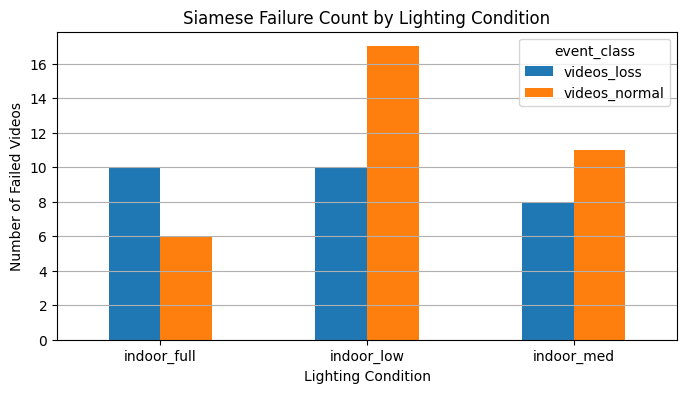

In [31]:
failure_pivot = failure_summary.pivot(index="lighting", columns="event_class", values="failures").fillna(0)

failure_pivot.plot(kind="bar", figsize=(8, 4))

plt.xlabel("Lighting Condition")
plt.ylabel("Number of Failed Videos")
plt.title("Siamese Failure Count by Lighting Condition")
plt.xticks(rotation=0)
plt.grid(axis="y")
# plt.savefig("results/fig16_siamese_failure_count.png", dpi=300, bbox_inches="tight")
plt.show()

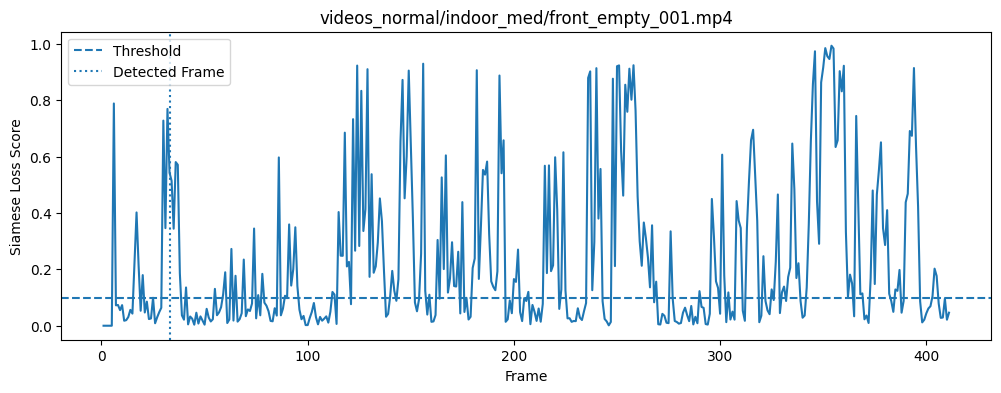

In [29]:
# Plot score timeline for one failed video

row = failed_videos.iloc[0]
video_path = resolve_test_video_path(row["filename"])

method = SiameseMethod(threshold=0.1, consecutive_frames=3)
result = method.predict_video(video_path)

frames = list(range(1, len(result["scores"]) + 1))

plt.figure(figsize=(12, 4))
plt.plot(frames, result["scores"])
plt.axhline(method.threshold, linestyle="--", label="Threshold")

if row["is_loss_event"] == 1:
    plt.axvline(row["loss_frame"], linestyle="--", label="Ground Truth Loss Frame")

if result["detected_frame"] != -1:
    plt.axvline(result["detected_frame"], linestyle=":", label="Detected Frame")

plt.xlabel("Frame")
plt.ylabel("Siamese Loss Score")
plt.title(row["filename"])
plt.legend()
plt.show()